In [33]:
## importing all the libraries 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
##generating the data
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.5, random_state=42)

In [35]:
##trying k valus from 1 to 10 

k_values = range(1, 11)
inertias = []
silhouettes = {}

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    if k > 1:
        silhouettes[k] = silhouette_score(X, km.labels_)
    print(f"K={k:2d}  inertia={km.inertia_:10.2f}")

K= 1  inertia=  35289.01
K= 2  inertia=  16949.26
K= 3  inertia=   4497.69
K= 4  inertia=   2126.04
K= 5  inertia=   1912.16
K= 6  inertia=   1702.92
K= 7  inertia=   1516.95
K= 8  inertia=   1311.75
K= 9  inertia=   1212.02
K=10  inertia=   1091.26


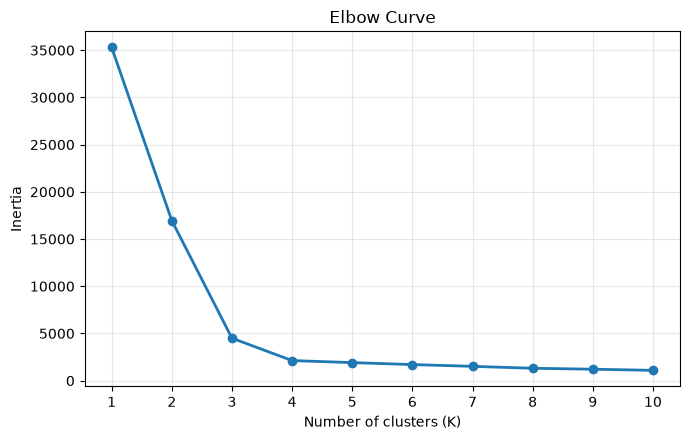

In [36]:
##plotting the inertia values

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), inertias, marker="o", linewidth=2)
plt.xticks(list(k_values))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=350)
plt.show()

In [37]:
## selecting the best k 
best_k_by_silhouette = max(silhouettes, key=silhouettes.get)
print("best k by silhouette score:", best_k_by_silhouette)

best k by silhouette score: 3


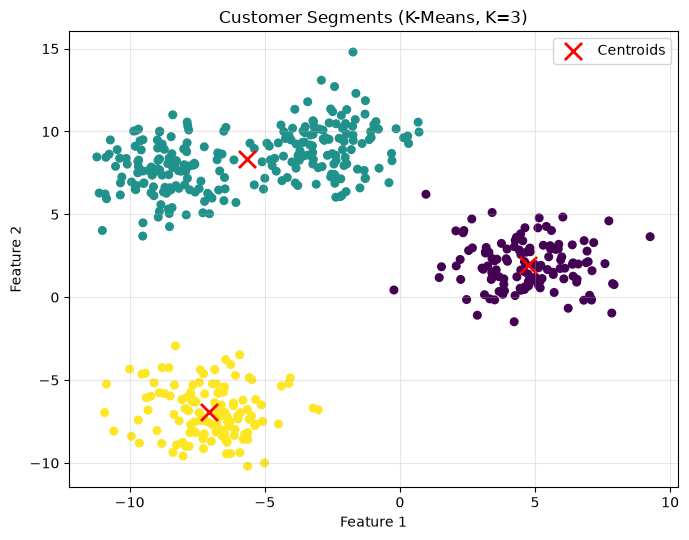

In [ ]:
## plotting the best cluster solution
best_k = best_k_by_silhouette
final_km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = final_km.fit_predict(X)

plt.figure(figsize=(7, 5.5))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="viridis", s=30)
plt.scatter(final_km.cluster_centers_[:, 0], final_km.cluster_centers_[:, 1], c="red", marker="x", s=150, linewidths=2, label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Customer Segments (K-Means, K={best_k})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("customer_clusters.png", dpi=300)
plt.show()

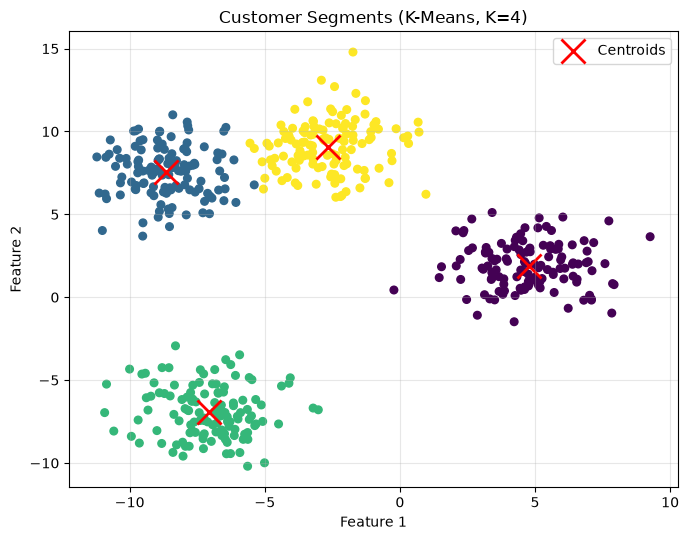

In [55]:
## here we can se the best k-cluster is  4  instead of 3 so we are going to select best_k = 4  
config_k = 4
best_k = config_k
final_km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = final_km.fit_predict(X)

plt.figure(figsize=(7, 5.5))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="viridis", s=30)
plt.scatter(final_km.cluster_centers_[:, 0], final_km.cluster_centers_[:, 1], c="red", marker="x", s=300, linewidths=2, label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Customer Segments (K-Means, K={best_k})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("customer_clusters_best_k_4.png", dpi=300)
plt.show()

In [56]:
print("\nCustomers per segment:")
for c in range(config_k):
    print(f"Segment {c}: {np.sum(cluster_labels == c)} customers")


Customers per segment:
Segment 0: 125 customers
Segment 1: 124 customers
Segment 2: 125 customers
Segment 3: 126 customers
